In [1]:
from pathlib import Path
import pandas as pd
from statsmodels.stats.multitest import multipletests

# ============================================================
# CREB5 secondary contextualization — frozen source data
# Source: AD Progression Atlas sample-level portal
# Accessed: 2026-09-27
# ============================================================

ROOT = Path(".")
SOURCE_DIR = ROOT / "source_data"
OUTPUT_DIR = ROOT / "outputs"

SOURCE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Local pathology correlations
# Portal-reported R and P values
# ------------------------------------------------------------

local = pd.DataFrame({
    "region": ["EC", "ITG", "PFC", "V2", "V1"],

    "abeta_r": [-0.091, 0.300, -0.0088, 0.350, -0.130],
    "abeta_p": [0.710, 0.100, 0.970, 0.048, 0.500],

    "ptau_tau_r": [-0.120, 0.250, 0.100, 0.028, -0.042],
    "ptau_tau_p": [0.580, 0.170, 0.610, 0.880, 0.820],
})

# One prespecified secondary family = 10 local-pathology tests
all_local_p = list(local["abeta_p"]) + list(local["ptau_tau_p"])
all_local_q = multipletests(all_local_p, method="fdr_bh")[1]

local["abeta_bh_q"] = all_local_q[:5]
local["ptau_tau_bh_q"] = all_local_q[5:]

local["gene"] = "CREB5"
local["cell_type"] = "astrocytes"
local["source"] = "AD Progression Atlas"
local["accession"] = "GSE268599"
local["access_date"] = "2026-09-27"
local["r_origin"] = "portal-reported"
local["p_origin"] = "portal-reported"
local["q_origin"] = "calculated in present study"

local.to_csv(
    SOURCE_DIR / "gse268599_creb5_local_pathology.csv",
    index=False
)

# ------------------------------------------------------------
# 2. Braak comparisons
# B1 = Braak 0/I/II
# B2 = Braak III/IV
# B3 = Braak V/VI
# ------------------------------------------------------------

braak = pd.DataFrame({
    "region": ["EC", "ITG", "PFC", "V2", "V1"],
    "comparison": ["B1_vs_B3"] * 5,
    "braak_group_1": ["B1 (0/I/II)"] * 5,
    "braak_group_2": ["B3 (V/VI)"] * 5,

    # portal-reported pairwise values
    "portal_p": [
        3.17e-2,
        2.49e-4,
        8.31e-3,
        2.87e-4,
        1.58e-5
    ],

    "direction": ["B3 > B1"] * 5,
})

braak["additional_bh_q"] = multipletests(
    braak["portal_p"],
    method="fdr_bh"
)[1]

braak["gene"] = "CREB5"
braak["cell_type"] = "astrocytes"
braak["source"] = "AD Progression Atlas"
braak["accession"] = "GSE268599"
braak["access_date"] = "2026-09-27"
braak["p_origin"] = "portal-reported"
braak["q_origin"] = "calculated in present study"

braak.to_csv(
    SOURCE_DIR / "gse268599_creb5_braak.csv",
    index=False
)

# Additional displayed Braak comparison
braak_extra = pd.DataFrame({
    "region": ["V1"],
    "comparison": ["B1_vs_B2"],
    "braak_group_1": ["B1 (0/I/II)"],
    "braak_group_2": ["B2 (III/IV)"],
    "portal_p": [3.14e-2],
    "direction": ["B2 > B1"],
    "gene": ["CREB5"],
    "cell_type": ["astrocytes"],
    "source": ["AD Progression Atlas"],
    "accession": ["GSE268599"],
    "access_date": ["2026-09-27"],
    "p_origin": ["portal-reported"],
})

braak_extra.to_csv(
    SOURCE_DIR / "gse268599_creb5_braak_additional.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Pathology-group comparisons
# Keep exactly as portal-reported.
# DO NOT apply selective FDR correction because the complete
# family of portal pairwise tests is unavailable.
# ------------------------------------------------------------

pathology_groups = pd.DataFrame([
    ["ITG", "1_vs_3", 3.17e-3],
    ["ITG", "1_vs_4", 1.28e-2],

    ["V2",  "1_vs_3", 7.41e-3],
    ["V2",  "1_vs_4", 5.38e-3],

    ["V1",  "1_vs_3", 9.39e-4],
    ["V1",  "1_vs_4", 9.39e-4],
], columns=["region", "comparison", "portal_p"])

pathology_groups["gene"] = "CREB5"
pathology_groups["cell_type"] = "astrocytes"
pathology_groups["source"] = "AD Progression Atlas"
pathology_groups["accession"] = "GSE268599"
pathology_groups["access_date"] = "2026-09-27"
pathology_groups["p_origin"] = "portal-reported"
pathology_groups["multiplicity_note"] = (
    "No additional correction applied because complete "
    "portal pairwise-comparison family was unavailable."
)

pathology_groups.to_csv(
    SOURCE_DIR / "gse268599_creb5_pathology_groups.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Publication Table 5
# ------------------------------------------------------------

table5 = (
    local[
        [
            "region",
            "abeta_r",
            "abeta_p",
            "abeta_bh_q",
            "ptau_tau_r",
            "ptau_tau_p",
            "ptau_tau_bh_q",
        ]
    ]
    .merge(
        braak[
            [
                "region",
                "portal_p",
                "additional_bh_q",
                "direction",
            ]
        ],
        on="region",
        how="left",
    )
    .rename(columns={
        "region": "Region",
        "abeta_r": "Abeta_R",
        "abeta_p": "Abeta_P",
        "abeta_bh_q": "Abeta_BH_q",
        "ptau_tau_r": "pTauTau_R",
        "ptau_tau_p": "pTauTau_P",
        "ptau_tau_bh_q": "pTauTau_BH_q",
        "portal_p": "Braak_B1_vs_B3_portal_P",
        "additional_bh_q": "Braak_B1_vs_B3_additional_BH_q",
        "direction": "Braak_direction",
    })
)

table5.to_csv(
    OUTPUT_DIR / "Table5_GSE268599_CREB5_context.csv",
    index=False
)

display(table5)

print("\nFILES CREATED:")
for p in sorted(SOURCE_DIR.glob("*.csv")):
    print(" -", p)

print(" -", OUTPUT_DIR / "Table5_GSE268599_CREB5_context.csv")

,Region,Abeta_R,Abeta_P,Abeta_BH_q,pTauTau_R,pTauTau_P,pTauTau_BH_q,Braak_B1_vs_B3_portal_P,Braak_B1_vs_B3_additional_BH_q,Braak_direction
0,EC,-0.0910,0.710,0.97,-0.120,0.58,0.970000,0.031700,0.031700,B3 > B1
1,ITG,0.3000,0.100,0.50,0.250,0.17,0.566667,0.000249,0.000478,B3 > B1
2,PFC,-0.0088,0.970,0.97,0.100,0.61,0.970000,0.008310,0.010387,B3 > B1
3,V2,0.3500,0.048,0.48,0.028,0.88,0.970000,0.000287,0.000478,B3 > B1
4,V1,-0.1300,0.500,0.97,-0.042,0.82,0.970000,0.000016,0.000079,B3 > B1



FILES CREATED:
 - source_data/gse268599_creb5_braak.csv
 - source_data/gse268599_creb5_braak_additional.csv
 - source_data/gse268599_creb5_local_pathology.csv
 - source_data/gse268599_creb5_pathology_groups.csv
 - outputs/Table5_GSE268599_CREB5_context.csv


In [2]:
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

SOURCE_DIR = Path("source_data")
OUTPUT_DIR = Path("outputs")

# ============================================================
# Load frozen files
# ============================================================

local = pd.read_csv(SOURCE_DIR / "gse268599_creb5_local_pathology.csv")
braak = pd.read_csv(SOURCE_DIR / "gse268599_creb5_braak.csv")
braak_extra = pd.read_csv(SOURCE_DIR / "gse268599_creb5_braak_additional.csv")
pathgrp = pd.read_csv(SOURCE_DIR / "gse268599_creb5_pathology_groups.csv")
table5 = pd.read_csv(OUTPUT_DIR / "Table5_GSE268599_CREB5_context.csv")

expected_regions = ["EC", "ITG", "PFC", "V2", "V1"]

# ============================================================
# QA 1 — structural checks
# ============================================================

assert local["region"].tolist() == expected_regions
assert braak["region"].tolist() == expected_regions
assert table5["Region"].tolist() == expected_regions

assert len(local) == 5
assert len(braak) == 5
assert len(braak_extra) == 1
assert len(pathgrp) == 6
assert len(table5) == 5

assert set(local["gene"]) == {"CREB5"}
assert set(braak["gene"]) == {"CREB5"}

assert set(local["cell_type"]) == {"astrocytes"}
assert set(braak["cell_type"]) == {"astrocytes"}

assert set(local["accession"]) == {"GSE268599"}
assert set(braak["accession"]) == {"GSE268599"}

# ============================================================
# QA 2 — freeze exact portal-reported values
# ============================================================

expected_abeta_r = np.array([
    -0.091,
     0.300,
    -0.0088,
     0.350,
    -0.130
])

expected_abeta_p = np.array([
    0.710,
    0.100,
    0.970,
    0.048,
    0.500
])

expected_ptau_r = np.array([
    -0.120,
     0.250,
     0.100,
     0.028,
    -0.042
])

expected_ptau_p = np.array([
    0.580,
    0.170,
    0.610,
    0.880,
    0.820
])

expected_braak_p = np.array([
    3.17e-2,
    2.49e-4,
    8.31e-3,
    2.87e-4,
    1.58e-5
])

assert np.allclose(local["abeta_r"], expected_abeta_r)
assert np.allclose(local["abeta_p"], expected_abeta_p)

assert np.allclose(local["ptau_tau_r"], expected_ptau_r)
assert np.allclose(local["ptau_tau_p"], expected_ptau_p)

assert np.allclose(braak["portal_p"], expected_braak_p)

# ============================================================
# QA 3 — independently recompute 10-test local-pathology BH
# ============================================================

local_p_family = np.concatenate([
    local["abeta_p"].to_numpy(),
    local["ptau_tau_p"].to_numpy()
])

recomputed_local_q = multipletests(
    local_p_family,
    method="fdr_bh"
)[1]

assert np.allclose(
    local["abeta_bh_q"],
    recomputed_local_q[:5]
)

assert np.allclose(
    local["ptau_tau_bh_q"],
    recomputed_local_q[5:]
)

# Critical biological/statistical assertion:
# NONE of the 10 local pathology tests survives q < 0.05
assert not np.any(recomputed_local_q < 0.05)

# V2 Aβ must remain nominal but NOT FDR significant
v2 = local.loc[local["region"] == "V2"].iloc[0]

assert np.isclose(v2["abeta_p"], 0.048)
assert np.isclose(v2["abeta_bh_q"], 0.48)
assert v2["abeta_p"] < 0.05
assert v2["abeta_bh_q"] >= 0.05

# ============================================================
# QA 4 — independently recompute 5-test Braak BH
# ============================================================

recomputed_braak_q = multipletests(
    braak["portal_p"],
    method="fdr_bh"
)[1]

assert np.allclose(
    braak["additional_bh_q"],
    recomputed_braak_q
)

# All five displayed B1-vs-B3 regional comparisons
# must remain significant after our additional BH correction
assert np.all(recomputed_braak_q < 0.05)

# All five directions must be advanced > early
assert set(braak["direction"]) == {"B3 > B1"}

# ============================================================
# QA 5 — additional Braak comparison
# ============================================================

assert braak_extra.loc[0, "region"] == "V1"
assert braak_extra.loc[0, "comparison"] == "B1_vs_B2"
assert np.isclose(braak_extra.loc[0, "portal_p"], 0.0314)
assert braak_extra.loc[0, "direction"] == "B2 > B1"

# ============================================================
# QA 6 — pathology-group supportive comparisons
# ============================================================

expected_pathgrp = {
    ("ITG", "1_vs_3"): 3.17e-3,
    ("ITG", "1_vs_4"): 1.28e-2,
    ("V2",  "1_vs_3"): 7.41e-3,
    ("V2",  "1_vs_4"): 5.38e-3,
    ("V1",  "1_vs_3"): 9.39e-4,
    ("V1",  "1_vs_4"): 9.39e-4,
}

observed_pathgrp = {
    (row.region, row.comparison): row.portal_p
    for row in pathgrp.itertuples()
}

assert set(observed_pathgrp) == set(expected_pathgrp)

for key, expected_p in expected_pathgrp.items():
    assert np.isclose(observed_pathgrp[key], expected_p)

# Ensure we did NOT create a selectively corrected q column
assert not any(
    col.lower() in {"q", "fdr", "bh_q", "adjusted_p"}
    for col in pathgrp.columns
)

# ============================================================
# QA 7 — Table 5 must exactly reflect frozen source files
# ============================================================

for region in expected_regions:

    l = local.loc[local["region"] == region].iloc[0]
    b = braak.loc[braak["region"] == region].iloc[0]
    t = table5.loc[table5["Region"] == region].iloc[0]

    assert np.isclose(t["Abeta_R"], l["abeta_r"])
    assert np.isclose(t["Abeta_P"], l["abeta_p"])
    assert np.isclose(t["Abeta_BH_q"], l["abeta_bh_q"])

    assert np.isclose(t["pTauTau_R"], l["ptau_tau_r"])
    assert np.isclose(t["pTauTau_P"], l["ptau_tau_p"])
    assert np.isclose(t["pTauTau_BH_q"], l["ptau_tau_bh_q"])

    assert np.isclose(
        t["Braak_B1_vs_B3_portal_P"],
        b["portal_p"]
    )

    assert np.isclose(
        t["Braak_B1_vs_B3_additional_BH_q"],
        b["additional_bh_q"]
    )

    assert t["Braak_direction"] == "B3 > B1"

# ============================================================
# QA 8 — provenance terminology
# ============================================================

assert set(local["r_origin"]) == {"portal-reported"}
assert set(local["p_origin"]) == {"portal-reported"}
assert set(local["q_origin"]) == {"calculated in present study"}

assert set(braak["p_origin"]) == {"portal-reported"}
assert set(braak["q_origin"]) == {"calculated in present study"}

# ============================================================
# Write machine-readable QA report
# ============================================================

qa_report = {
    "status": "PASS",
    "gene": "CREB5",
    "accession": "GSE268599",
    "cell_type": "astrocytes",
    "regions": expected_regions,

    "local_pathology_tests": 10,
    "local_pathology_q_lt_0.05": int(
        np.sum(recomputed_local_q < 0.05)
    ),

    "braak_B1_vs_B3_tests": 5,
    "braak_B1_vs_B3_q_lt_0.05": int(
        np.sum(recomputed_braak_q < 0.05)
    ),

    "minimum_braak_q": float(
        np.min(recomputed_braak_q)
    ),

    "maximum_braak_q": float(
        np.max(recomputed_braak_q)
    ),

    "notes": [
        "Aβ and pTau/Tau form one 10-test BH family.",
        "Braak B1-vs-B3 forms a separate 5-test BH family.",
        "Pathology-group portal P values were not selectively re-corrected.",
        "Portal P values are distinguished from calculations performed in the present study.",
        "Five regions belong to one multi-region study and are not five independent cohorts."
    ]
}

qa_path = OUTPUT_DIR / "QA_gse268599_creb5_context.json"

with open(qa_path, "w", encoding="utf-8") as f:
    json.dump(qa_report, f, indent=2)

# ============================================================
# SHA256 provenance manifest
# ============================================================

files_to_hash = [
    SOURCE_DIR / "gse268599_creb5_local_pathology.csv",
    SOURCE_DIR / "gse268599_creb5_braak.csv",
    SOURCE_DIR / "gse268599_creb5_braak_additional.csv",
    SOURCE_DIR / "gse268599_creb5_pathology_groups.csv",
    OUTPUT_DIR / "Table5_GSE268599_CREB5_context.csv",
    qa_path,
]

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()

manifest = pd.DataFrame({
    "file": [str(p) for p in files_to_hash],
    "sha256": [sha256_file(p) for p in files_to_hash]
})

manifest.to_csv(
    OUTPUT_DIR / "secondary_context_sha256_manifest.csv",
    index=False
)

# ============================================================
# Final report
# ============================================================

print("==========================================")
print("CREB5 GSE268599 SECONDARY ANALYSIS QA: PASS")
print("==========================================")
print()
print("Regions:", ", ".join(expected_regions))
print("Local pathology tests:", len(recomputed_local_q))
print(
    "Local pathology tests surviving BH:",
    int(np.sum(recomputed_local_q < 0.05))
)
print()
print("Braak B1-vs-B3 tests:", len(recomputed_braak_q))
print(
    "Braak comparisons surviving additional BH:",
    int(np.sum(recomputed_braak_q < 0.05))
)
print()
print("QA report:", qa_path)
print(
    "SHA256 manifest:",
    OUTPUT_DIR / "secondary_context_sha256_manifest.csv"
)

CREB5 GSE268599 SECONDARY ANALYSIS QA: PASS

Regions: EC, ITG, PFC, V2, V1
Local pathology tests: 10
Local pathology tests surviving BH: 0

Braak B1-vs-B3 tests: 5
Braak comparisons surviving additional BH: 5

QA report: outputs/QA_gse268599_creb5_context.json
SHA256 manifest: outputs/secondary_context_sha256_manifest.csv


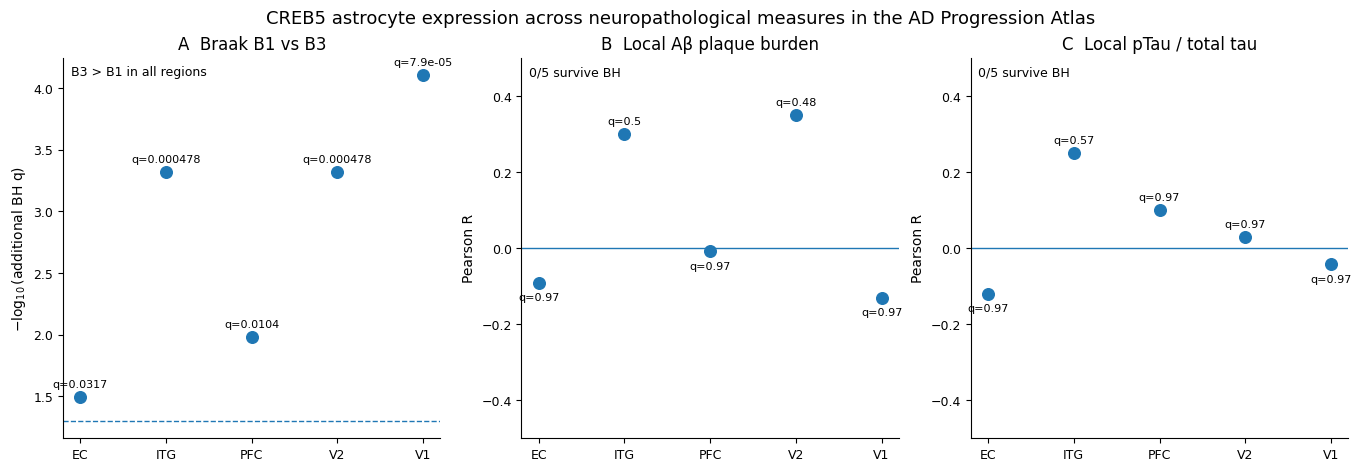

CREATED:
 - outputs/Supplementary_Figure_S6_GSE268599_CREB5.png
 - outputs/Supplementary_Figure_S6_GSE268599_CREB5.pdf
 - outputs/Supplementary_Figure_S6_GSE268599_CREB5.svg


In [3]:
# ============================================================
# CELL 3 — Supplementary Figure S6
# CREB5 neuropathological context in GSE268599
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SOURCE_DIR = Path("source_data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Load frozen, QA-passed source tables
# ------------------------------------------------------------

local = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_local_pathology.csv"
)

braak = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_braak.csv"
)

regions = ["EC", "ITG", "PFC", "V2", "V1"]

local = (
    local.set_index("region")
    .loc[regions]
    .reset_index()
)

braak = (
    braak.set_index("region")
    .loc[regions]
    .reset_index()
)

# ------------------------------------------------------------
# Derived plotting quantity
# IMPORTANT:
# this is significance strength, NOT an effect size
# ------------------------------------------------------------

braak["minus_log10_q"] = -np.log10(
    braak["additional_bh_q"]
)

bh_threshold = -np.log10(0.05)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(13.5, 4.6),
    constrained_layout=True
)

# ============================================================
# PANEL A — Braak B1 vs B3
# ============================================================

ax = axes[0]

x = np.arange(len(regions))

ax.scatter(
    x,
    braak["minus_log10_q"],
    s=70
)

ax.axhline(
    bh_threshold,
    linestyle="--",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(regions)

ax.set_ylabel(
    r"$-\log_{10}$(additional BH q)"
)

ax.set_title(
    "A  Braak B1 vs B3"
)

for i, row in braak.iterrows():
    ax.annotate(
        f"q={row['additional_bh_q']:.3g}",
        (i, row["minus_log10_q"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.text(
    0.02,
    0.98,
    "B3 > B1 in all regions",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

# ============================================================
# PANEL B — local Aβ plaque correlation
# ============================================================

ax = axes[1]

ax.axhline(
    0,
    linewidth=1
)

ax.scatter(
    x,
    local["abeta_r"],
    s=70
)

ax.set_xticks(x)
ax.set_xticklabels(regions)

ax.set_ylabel(
    "Pearson R"
)

ax.set_title(
    "B  Local Aβ plaque burden"
)

ax.set_ylim(-0.5, 0.5)

for i, row in local.iterrows():
    ax.annotate(
        f"q={row['abeta_bh_q']:.2g}",
        (i, row["abeta_r"]),
        xytext=(0, 7 if row["abeta_r"] >= 0 else -13),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.text(
    0.02,
    0.98,
    "0/5 survive BH",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

# ============================================================
# PANEL C — local pTau / total tau correlation
# ============================================================

ax = axes[2]

ax.axhline(
    0,
    linewidth=1
)

ax.scatter(
    x,
    local["ptau_tau_r"],
    s=70
)

ax.set_xticks(x)
ax.set_xticklabels(regions)

ax.set_ylabel(
    "Pearson R"
)

ax.set_title(
    "C  Local pTau / total tau"
)

ax.set_ylim(-0.5, 0.5)

for i, row in local.iterrows():
    ax.annotate(
        f"q={row['ptau_tau_bh_q']:.2g}",
        (i, row["ptau_tau_r"]),
        xytext=(0, 7 if row["ptau_tau_r"] >= 0 else -13),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.text(
    0.02,
    0.98,
    "0/5 survive BH",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

# ------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

fig.suptitle(
    "CREB5 astrocyte expression across neuropathological measures "
    "in the AD Progression Atlas",
    fontsize=13
)

# ------------------------------------------------------------
# Save publication outputs
# ------------------------------------------------------------

png_path = OUTPUT_DIR / "Supplementary_Figure_S6_GSE268599_CREB5.png"
pdf_path = OUTPUT_DIR / "Supplementary_Figure_S6_GSE268599_CREB5.pdf"
svg_path = OUTPUT_DIR / "Supplementary_Figure_S6_GSE268599_CREB5.svg"

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

fig.savefig(
    svg_path,
    bbox_inches="tight"
)

plt.show()

print("CREATED:")
print(" -", png_path)
print(" -", pdf_path)
print(" -", svg_path)

In [4]:
# ============================================================
# CELL 4 — Supplementary Table S4
# Complete GSE268599 CREB5 neuropathological contextualization
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

SOURCE_DIR = Path("source_data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Load frozen data
# ------------------------------------------------------------

local = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_local_pathology.csv"
)

braak = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_braak.csv"
)

braak_extra = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_braak_additional.csv"
)

pathgrp = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_pathology_groups.csv"
)

rows = []

# ============================================================
# 1. Local Aβ correlations
# ============================================================

for _, r in local.iterrows():

    rows.append({
        "Region": r["region"],
        "Analysis": "Local pathology correlation",
        "Endpoint": "Aβ plaque burden",
        "Comparison_or_measure": "CREB5 vs local Aβ",
        "Statistic": "Pearson R",
        "Statistic_value": r["abeta_r"],
        "Portal_P": r["abeta_p"],
        "Additional_BH_q": r["abeta_bh_q"],
        "Direction": (
            "positive" if r["abeta_r"] > 0
            else "negative" if r["abeta_r"] < 0
            else "zero"
        ),
        "Multiplicity_family":
            "10 local-pathology tests "
            "(5 Aβ + 5 pTau/total tau)",
        "Statistical_origin": "Portal-reported R and P",
        "Interpretation_note":
            "Additional BH correction calculated in present study."
    })

# ============================================================
# 2. Local pTau / total tau correlations
# ============================================================

for _, r in local.iterrows():

    rows.append({
        "Region": r["region"],
        "Analysis": "Local pathology correlation",
        "Endpoint": "pTau / total tau",
        "Comparison_or_measure": "CREB5 vs local pTau/total tau",
        "Statistic": "Pearson R",
        "Statistic_value": r["ptau_tau_r"],
        "Portal_P": r["ptau_tau_p"],
        "Additional_BH_q": r["ptau_tau_bh_q"],
        "Direction": (
            "positive" if r["ptau_tau_r"] > 0
            else "negative" if r["ptau_tau_r"] < 0
            else "zero"
        ),
        "Multiplicity_family":
            "10 local-pathology tests "
            "(5 Aβ + 5 pTau/total tau)",
        "Statistical_origin": "Portal-reported R and P",
        "Interpretation_note":
            "Additional BH correction calculated in present study."
    })

# ============================================================
# 3. Braak B1 vs B3
# ============================================================

for _, r in braak.iterrows():

    rows.append({
        "Region": r["region"],
        "Analysis": "Braak-group comparison",
        "Endpoint": "Braak stage",
        "Comparison_or_measure": "B1 (0/I/II) vs B3 (V/VI)",
        "Statistic": "Portal pairwise comparison",
        "Statistic_value": np.nan,
        "Portal_P": r["portal_p"],
        "Additional_BH_q": r["additional_bh_q"],
        "Direction": r["direction"],
        "Multiplicity_family":
            "5 displayed regional B1-vs-B3 comparisons",
        "Statistical_origin": "Portal-reported P",
        "Interpretation_note":
            "Additional BH correction calculated in present study; "
            "portal test method/internal multiplicity not independently verified."
    })

# ============================================================
# 4. Additional V1 B1 vs B2 comparison
# ============================================================

for _, r in braak_extra.iterrows():

    rows.append({
        "Region": r["region"],
        "Analysis": "Braak-group comparison",
        "Endpoint": "Braak stage",
        "Comparison_or_measure": "B1 (0/I/II) vs B2 (III/IV)",
        "Statistic": "Portal pairwise comparison",
        "Statistic_value": np.nan,
        "Portal_P": r["portal_p"],
        "Additional_BH_q": np.nan,
        "Direction": r["direction"],
        "Multiplicity_family": "Not additionally corrected",
        "Statistical_origin": "Portal-reported P",
        "Interpretation_note":
            "Shown as descriptive additional portal comparison."
    })

# ============================================================
# 5. Pathology-group comparisons
# ============================================================

for _, r in pathgrp.iterrows():

    rows.append({
        "Region": r["region"],
        "Analysis": "Pathology-group comparison",
        "Endpoint": "AD pathology group",
        "Comparison_or_measure": r["comparison"],
        "Statistic": "Portal pairwise comparison",
        "Statistic_value": np.nan,
        "Portal_P": r["portal_p"],
        "Additional_BH_q": np.nan,
        "Direction": "later group differs from group 1",
        "Multiplicity_family":
            "Not additionally corrected",
        "Statistical_origin": "Portal-reported P",
        "Interpretation_note":
            "Descriptive only because the complete portal "
            "pairwise-comparison family was unavailable."
    })

# ============================================================
# Assemble table
# ============================================================

s4 = pd.DataFrame(rows)

# Preserve biologically logical regional order
region_order = {
    "EC": 0,
    "ITG": 1,
    "PFC": 2,
    "V2": 3,
    "V1": 4
}

analysis_order = {
    "Local pathology correlation": 0,
    "Braak-group comparison": 1,
    "Pathology-group comparison": 2
}

s4["_region_order"] = s4["Region"].map(region_order)
s4["_analysis_order"] = s4["Analysis"].map(analysis_order)

s4 = (
    s4.sort_values(
        ["_analysis_order", "_region_order", "Endpoint"]
    )
    .drop(columns=["_region_order", "_analysis_order"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Add fixed provenance columns
# ------------------------------------------------------------

s4["Gene"] = "CREB5"
s4["Cell_type"] = "astrocytes"
s4["Resource"] = "AD Progression Atlas"
s4["Accession"] = "GSE268599"
s4["Access_date"] = "2026-09-27"

# Reorder columns
s4 = s4[
    [
        "Gene",
        "Cell_type",
        "Resource",
        "Accession",
        "Region",
        "Analysis",
        "Endpoint",
        "Comparison_or_measure",
        "Statistic",
        "Statistic_value",
        "Portal_P",
        "Additional_BH_q",
        "Direction",
        "Multiplicity_family",
        "Statistical_origin",
        "Interpretation_note",
        "Access_date"
    ]
]

# ============================================================
# Save
# ============================================================

csv_path = OUTPUT_DIR / "Supplementary_Table_S4_GSE268599_CREB5.csv"
xlsx_path = OUTPUT_DIR / "Supplementary_Table_S4_GSE268599_CREB5.xlsx"

s4.to_csv(csv_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    s4.to_excel(
        writer,
        sheet_name="GSE268599_CREB5",
        index=False
    )

display(s4)

print("==============================================")
print("SUPPLEMENTARY TABLE S4 GENERATED")
print("==============================================")
print("Rows:", len(s4))
print("CSV :", csv_path)
print("XLSX:", xlsx_path)

,Gene,Cell_type,Resource,Accession,Region,Analysis,Endpoint,Comparison_or_measure,Statistic,Statistic_value,Portal_P,Additional_BH_q,Direction,Multiplicity_family,Statistical_origin,Interpretation_note,Access_date
0,CREB5,astrocytes,AD Progression Atlas,GSE268599,EC,Local pathology correlation,Aβ plaque burden,CREB5 vs local Aβ,Pearson R,-0.0910,0.710000,0.970000,negative,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
1,CREB5,astrocytes,AD Progression Atlas,GSE268599,EC,Local pathology correlation,pTau / total tau,CREB5 vs local pTau/total tau,Pearson R,-0.1200,0.580000,0.970000,negative,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
2,CREB5,astrocytes,AD Progression Atlas,GSE268599,ITG,Local pathology correlation,Aβ plaque burden,CREB5 vs local Aβ,Pearson R,0.3000,0.100000,0.500000,positive,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
3,CREB5,astrocytes,AD Progression Atlas,GSE268599,ITG,Local pathology correlation,pTau / total tau,CREB5 vs local pTau/total tau,Pearson R,0.2500,0.170000,0.566667,positive,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
4,CREB5,astrocytes,AD Progression Atlas,GSE268599,PFC,Local pathology correlation,Aβ plaque burden,CREB5 vs local Aβ,Pearson R,-0.0088,0.970000,0.970000,negative,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
5,CREB5,astrocytes,AD Progression Atlas,GSE268599,PFC,Local pathology correlation,pTau / total tau,CREB5 vs local pTau/total tau,Pearson R,0.1000,0.610000,0.970000,positive,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
6,CREB5,astrocytes,AD Progression Atlas,GSE268599,V2,Local pathology correlation,Aβ plaque burden,CREB5 vs local Aβ,Pearson R,0.3500,0.048000,0.480000,positive,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
7,CREB5,astrocytes,AD Progression Atlas,GSE268599,V2,Local pathology correlation,pTau / total tau,CREB5 vs local pTau/total tau,Pearson R,0.0280,0.880000,0.970000,positive,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
8,CREB5,astrocytes,AD Progression Atlas,GSE268599,V1,Local pathology correlation,Aβ plaque burden,CREB5 vs local Aβ,Pearson R,-0.1300,0.500000,0.970000,negative,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27
9,CREB5,astrocytes,AD Progression Atlas,GSE268599,V1,Local pathology correlation,pTau / total tau,CREB5 vs local pTau/total tau,Pearson R,-0.0420,0.820000,0.970000,negative,10 local-pathology tests (5 Aβ + 5 pTau/total ...,Portal-reported R and P,Additional BH correction calculated in present...,2026-09-27


SUPPLEMENTARY TABLE S4 GENERATED
Rows: 22
CSV : outputs/Supplementary_Table_S4_GSE268599_CREB5.csv
XLSX: outputs/Supplementary_Table_S4_GSE268599_CREB5.xlsx


In [6]:
# ============================================================
# CELL 4B — Word-ready Supplementary Table S4
# Creates compact panels from the full provenance table
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

SOURCE_DIR = Path("source_data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

local = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_local_pathology.csv"
)

braak = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_braak.csv"
)

braak_extra = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_braak_additional.csv"
)

pathgrp = pd.read_csv(
    SOURCE_DIR / "gse268599_creb5_pathology_groups.csv"
)

regions = ["EC", "ITG", "PFC", "V2", "V1"]

# ------------------------------------------------------------
# S4A — Local pathology
# ------------------------------------------------------------

s4a = (
    local.set_index("region")
    .loc[regions]
    .reset_index()
    [
        [
            "region",
            "abeta_r",
            "abeta_p",
            "abeta_bh_q",
            "ptau_tau_r",
            "ptau_tau_p",
            "ptau_tau_bh_q",
        ]
    ]
    .rename(columns={
        "region": "Region",
        "abeta_r": "Aβ R",
        "abeta_p": "Aβ P",
        "abeta_bh_q": "Aβ BH q",
        "ptau_tau_r": "pTau/Tau R",
        "ptau_tau_p": "pTau/Tau P",
        "ptau_tau_bh_q": "pTau/Tau BH q",
    })
)

# ------------------------------------------------------------
# S4B — Braak
# ------------------------------------------------------------

s4b = braak[
    ["region", "comparison", "portal_p", "additional_bh_q", "direction"]
].copy()

s4b["comparison"] = "B1 (0/I/II) vs B3 (V/VI)"

s4b = s4b.rename(columns={
    "region": "Region",
    "comparison": "Comparison",
    "portal_p": "Portal P",
    "additional_bh_q": "Additional BH q",
    "direction": "Direction",
})

# Add V1 B1 vs B2 as descriptive row
extra = pd.DataFrame([{
    "Region": "V1",
    "Comparison": "B1 (0/I/II) vs B2 (III/IV)",
    "Portal P": 0.0314,
    "Additional BH q": np.nan,
    "Direction": "B2 > B1",
}])

s4b = pd.concat([s4b, extra], ignore_index=True)

# ------------------------------------------------------------
# S4C — Pathology groups
# ------------------------------------------------------------

s4c = pathgrp[
    ["region", "comparison", "portal_p"]
].copy()

s4c["Endpoint"] = "AD pathology group"

s4c = s4c[
    ["region", "Endpoint", "comparison", "portal_p"]
].rename(columns={
    "region": "Region",
    "comparison": "Comparison",
    "portal_p": "Portal P",
})

# ------------------------------------------------------------
# Save compact Word-ready workbook
# ------------------------------------------------------------

xlsx_path = OUTPUT_DIR / "Supplementary_Table_S4_WORD_READY.xlsx"

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    s4a.to_excel(writer, sheet_name="S4A_Local_pathology", index=False)
    s4b.to_excel(writer, sheet_name="S4B_Braak", index=False)
    s4c.to_excel(writer, sheet_name="S4C_Pathology_groups", index=False)

print("S4A")
display(s4a)

print("\nS4B")
display(s4b)

print("\nS4C")
display(s4c)

print("\nCREATED:")
print(xlsx_path)

S4A


,Region,Aβ R,Aβ P,Aβ BH q,pTau/Tau R,pTau/Tau P,pTau/Tau BH q
0,EC,-0.0910,0.710,0.97,-0.120,0.58,0.970000
1,ITG,0.3000,0.100,0.50,0.250,0.17,0.566667
2,PFC,-0.0088,0.970,0.97,0.100,0.61,0.970000
3,V2,0.3500,0.048,0.48,0.028,0.88,0.970000
4,V1,-0.1300,0.500,0.97,-0.042,0.82,0.970000



S4B


,Region,Comparison,Portal P,Additional BH q,Direction
0,EC,B1 (0/I/II) vs B3 (V/VI),0.031700,0.031700,B3 > B1
1,ITG,B1 (0/I/II) vs B3 (V/VI),0.000249,0.000478,B3 > B1
2,PFC,B1 (0/I/II) vs B3 (V/VI),0.008310,0.010387,B3 > B1
3,V2,B1 (0/I/II) vs B3 (V/VI),0.000287,0.000478,B3 > B1
4,V1,B1 (0/I/II) vs B3 (V/VI),0.000016,0.000079,B3 > B1
5,V1,B1 (0/I/II) vs B2 (III/IV),0.031400,NaN,B2 > B1



S4C


,Region,Endpoint,Comparison,Portal P
0,ITG,AD pathology group,1_vs_3,0.003170
1,ITG,AD pathology group,1_vs_4,0.012800
2,V2,AD pathology group,1_vs_3,0.007410
3,V2,AD pathology group,1_vs_4,0.005380
4,V1,AD pathology group,1_vs_3,0.000939
5,V1,AD pathology group,1_vs_4,0.000939



CREATED:
outputs/Supplementary_Table_S4_WORD_READY.xlsx


In [5]:
# ============================================================
# CELL 5 — HPA + Agora contextualization
# Freeze source values and generate Supplementary Table S5
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

SOURCE_DIR = Path("source_data")
OUTPUT_DIR = Path("outputs")

SOURCE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

ACCESS_DATE = "2026-09-27"

# ============================================================
# 1. HUMAN PROTEIN ATLAS
# ============================================================

hpa = pd.DataFrame([
    {
        "Resource": "Human Protein Atlas",
        "Domain": "Normal brain cell-type context",
        "Item": "CREB5",
        "Region_or_panel": "Single nuclei brain",
        "Metric": "Brain cluster specificity",
        "Value": (
            "Cell type enhanced "
            "(Oligodendrocyte, Committed oligodendrocyte precursor)"
        ),
        "Numeric_value": np.nan,
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Direction_or_status": "Not astrocyte-specific",
        "Evidence_origin": "HPA resource-reported classification",
        "Use_in_manuscript": "Contextual only",
        "Interpretation": (
            "CREB5 is not classified as a constitutive "
            "normal-brain astrocyte-specific transcript."
        ),
        "Access_date": ACCESS_DATE,
    }
])

hpa.to_csv(
    SOURCE_DIR / "hpa_creb5_context.csv",
    index=False
)

# ============================================================
# 2. AGORA — overall regional RNA expression
# Exact values displayed above bars in screenshot
# ============================================================

agora_expression = pd.DataFrame({
    "Region": [
        "ACC", "CBE", "DLPFC", "FP", "IFG",
        "PCC", "PHG", "STG", "TCX"
    ],
    "Log2_CPM": [
        4.99, 4.68, 4.80, 5.34, 5.62,
        4.88, 5.95, 5.70, 5.44
    ]
})

agora_expression["Resource"] = "Agora"
agora_expression["Domain"] = "Overall RNA expression"
agora_expression["Gene"] = "CREB5"
agora_expression["Evidence_origin"] = "Portal figure label"
agora_expression["Use_in_manuscript"] = "Contextual only"
agora_expression["Access_date"] = ACCESS_DATE

agora_expression.to_csv(
    SOURCE_DIR / "agora_creb5_overall_expression.csv",
    index=False
)

# ============================================================
# 3. AGORA — regional AD RNA differential-expression intervals
#
# IMPORTANT:
# Only interval endpoints printed directly on the forest plot
# are frozen here.
#
# We do NOT derive or invent exact point estimates.
# ============================================================

agora_de = pd.DataFrame({
    "Region": [
        "ACC", "CBE", "DLPFC", "FP", "IFG",
        "PCC", "PHG", "STG", "TCX"
    ],

    "CI_low": [
        -0.33,
        -0.23,
        -0.0094,
         0.024,
         0.036,
        -0.069,
         0.21,
        -0.038,
        -0.064
    ],

    "CI_high": [
        -0.084,
         0.16,
         0.21,
         0.32,
         0.34,
         0.19,
         0.51,
         0.27,
         0.32
    ],

    # Direction is based only on the displayed point position
    # relative to zero; exact point estimate was not printed.
    "Displayed_point_direction": [
        "negative",
        "negative",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive"
    ]
})

agora_de["CI_excludes_zero"] = (
    (agora_de["CI_low"] > 0) |
    (agora_de["CI_high"] < 0)
)

agora_de["Resource"] = "Agora"
agora_de["Domain"] = "AD diagnosis RNA differential expression"
agora_de["Gene"] = "CREB5"
agora_de["Comparison"] = "AD vs CN; males and females"
agora_de["Exact_point_estimate_available"] = False
agora_de["Evidence_origin"] = (
    "Portal forest plot; printed CI endpoints "
    "and visually displayed point direction"
)
agora_de["Use_in_manuscript"] = "Contextual only"
agora_de["Access_date"] = ACCESS_DATE

agora_de.to_csv(
    SOURCE_DIR / "agora_creb5_rna_differential_expression.csv",
    index=False
)

# ============================================================
# 4. AGORA — AD phenotype / hallmark panel
#
# The screenshot provides visible direction relative to OR=1,
# but does not print exact numerical OR / CI labels.
# Therefore freeze qualitative status only.
# ============================================================

agora_hallmarks = pd.DataFrame([
    {
        "Phenotype": "BRAAK",
        "Displayed_OR_position": ">1",
        "Qualitative_direction": "positive association",
    },
    {
        "Phenotype": "CERAD",
        "Displayed_OR_position": "<1",
        "Qualitative_direction": "inverse association",
    },
    {
        "Phenotype": "COGDX",
        "Displayed_OR_position": "<1",
        "Qualitative_direction": "inverse/near-null association",
    },
])

agora_hallmarks["Resource"] = "Agora"
agora_hallmarks["Domain"] = "Association with hallmarks of AD"
agora_hallmarks["Gene"] = "CREB5"
agora_hallmarks["Exact_OR_transcribed"] = False
agora_hallmarks["Evidence_origin"] = "Portal figure"
agora_hallmarks["Use_in_manuscript"] = "Descriptive contextualization only"
agora_hallmarks["Access_date"] = ACCESS_DATE

agora_hallmarks.to_csv(
    SOURCE_DIR / "agora_creb5_ad_hallmarks.csv",
    index=False
)

# ============================================================
# 5. AGORA — proteomic availability
# ============================================================

agora_protein = pd.DataFrame([
    {
        "Panel": "SRM",
        "Availability": "No data currently available"
    },
    {
        "Panel": "TMT",
        "Availability": "No data currently available"
    },
    {
        "Panel": "LFQ",
        "Availability": "No data currently available"
    },
])

agora_protein["Resource"] = "Agora"
agora_protein["Domain"] = "Proteomics"
agora_protein["Gene"] = "CREB5"
agora_protein["Evidence_origin"] = "Portal panel"
agora_protein["Use_in_manuscript"] = (
    "Absence of available proteomic validation; "
    "not a biological null result"
)
agora_protein["Access_date"] = ACCESS_DATE

agora_protein.to_csv(
    SOURCE_DIR / "agora_creb5_proteomics_availability.csv",
    index=False
)

# ============================================================
# 6. AGORA — metabolomics panel
#
# Record existence without making inferential claims.
# ============================================================

agora_metabolomics = pd.DataFrame([
    {
        "Resource": "Agora",
        "Domain": "Metabolomics",
        "Gene": "CREB5",
        "Item": "PC ae C40:1",
        "Comparison": "AD vs CN",
        "Status": "Portal comparison displayed",
        "Exact_inferential_statistics_transcribed": False,
        "Use_in_manuscript": "Not used for validation/inference",
        "Interpretation": (
            "Recorded for completeness only; "
            "not incorporated into the primary or secondary claims."
        ),
        "Access_date": ACCESS_DATE,
    }
])

agora_metabolomics.to_csv(
    SOURCE_DIR / "agora_creb5_metabolomics.csv",
    index=False
)

# ============================================================
# 7. BUILD SUPPLEMENTARY TABLE S5
# Long-form evidence ledger
# ============================================================

rows = []

# HPA
for _, r in hpa.iterrows():
    rows.append({
        "Resource": r["Resource"],
        "Evidence_domain": r["Domain"],
        "Region_or_item": r["Region_or_panel"],
        "Measure": r["Metric"],
        "Result": r["Value"],
        "Numeric_value": np.nan,
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Interpretation": r["Interpretation"],
        "Evidence_origin": r["Evidence_origin"],
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

# Agora overall expression
for _, r in agora_expression.iterrows():
    rows.append({
        "Resource": "Agora",
        "Evidence_domain": "Overall RNA expression",
        "Region_or_item": r["Region"],
        "Measure": "log2 CPM",
        "Result": f"{r['Log2_CPM']:.2f}",
        "Numeric_value": r["Log2_CPM"],
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Interpretation": "CREB5 detectable in bulk tissue",
        "Evidence_origin": r["Evidence_origin"],
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

# Agora regional RNA DE
for _, r in agora_de.iterrows():

    if r["CI_excludes_zero"]:
        ci_note = "displayed interval excludes zero"
    else:
        ci_note = "displayed interval crosses zero"

    rows.append({
        "Resource": "Agora",
        "Evidence_domain": "AD diagnosis RNA differential expression",
        "Region_or_item": r["Region"],
        "Measure": "Displayed log2FC interval",
        "Result": (
            f"{r['Displayed_point_direction']}; "
            f"interval {r['CI_low']} to {r['CI_high']}"
        ),
        "Numeric_value": np.nan,
        "Lower_bound": r["CI_low"],
        "Upper_bound": r["CI_high"],
        "Interpretation": ci_note,
        "Evidence_origin": r["Evidence_origin"],
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

# Agora hallmarks
for _, r in agora_hallmarks.iterrows():
    rows.append({
        "Resource": "Agora",
        "Evidence_domain": "AD phenotype association",
        "Region_or_item": r["Phenotype"],
        "Measure": "Displayed odds-ratio position",
        "Result": r["Displayed_OR_position"],
        "Numeric_value": np.nan,
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Interpretation": r["Qualitative_direction"],
        "Evidence_origin": r["Evidence_origin"],
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

# Agora proteomics
for _, r in agora_protein.iterrows():
    rows.append({
        "Resource": "Agora",
        "Evidence_domain": "Proteomics",
        "Region_or_item": r["Panel"],
        "Measure": "Data availability",
        "Result": r["Availability"],
        "Numeric_value": np.nan,
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Interpretation": (
            "No available CREB5 protein measurement in queried panel; "
            "not evidence of no protein effect."
        ),
        "Evidence_origin": r["Evidence_origin"],
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

# Agora metabolomics
for _, r in agora_metabolomics.iterrows():
    rows.append({
        "Resource": "Agora",
        "Evidence_domain": "Metabolomics",
        "Region_or_item": r["Item"],
        "Measure": r["Comparison"],
        "Result": r["Status"],
        "Numeric_value": np.nan,
        "Lower_bound": np.nan,
        "Upper_bound": np.nan,
        "Interpretation": r["Interpretation"],
        "Evidence_origin": "Portal figure",
        "Use_in_inference": r["Use_in_manuscript"],
        "Access_date": r["Access_date"],
    })

s5 = pd.DataFrame(rows)

# ============================================================
# QA
# ============================================================

assert len(hpa) == 1
assert len(agora_expression) == 9
assert len(agora_de) == 9
assert len(agora_hallmarks) == 3
assert len(agora_protein) == 3
assert len(agora_metabolomics) == 1

# Exact overall expression values
assert np.allclose(
    agora_expression["Log2_CPM"],
    [4.99, 4.68, 4.80, 5.34, 5.62, 4.88, 5.95, 5.70, 5.44]
)

# Regions whose displayed intervals exclude zero
observed_excluding = set(
    agora_de.loc[
        agora_de["CI_excludes_zero"],
        "Region"
    ]
)

expected_excluding = {"ACC", "FP", "IFG", "PHG"}

assert observed_excluding == expected_excluding

# No proteomic dataset must accidentally be represented as present
assert set(agora_protein["Availability"]) == {
    "No data currently available"
}

# HPA wording must remain explicit
assert "Oligodendrocyte" in hpa.loc[0, "Value"]
assert "astrocyte-specific" in hpa.loc[0, "Interpretation"]

# Expected S5 row count:
# 1 HPA + 9 expression + 9 RNA DE +
# 3 hallmarks + 3 protein + 1 metabolomics = 26
assert len(s5) == 26

# ============================================================
# SAVE
# ============================================================

csv_path = OUTPUT_DIR / "Supplementary_Table_S5_HPA_Agora_CREB5.csv"
xlsx_path = OUTPUT_DIR / "Supplementary_Table_S5_HPA_Agora_CREB5.xlsx"

s5.to_csv(csv_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:

    s5.to_excel(
        writer,
        sheet_name="Evidence_Ledger",
        index=False
    )

    hpa.to_excel(
        writer,
        sheet_name="HPA",
        index=False
    )

    agora_expression.to_excel(
        writer,
        sheet_name="Agora_RNA_expression",
        index=False
    )

    agora_de.to_excel(
        writer,
        sheet_name="Agora_RNA_DE",
        index=False
    )

    agora_hallmarks.to_excel(
        writer,
        sheet_name="Agora_AD_phenotypes",
        index=False
    )

    agora_protein.to_excel(
        writer,
        sheet_name="Agora_proteomics",
        index=False
    )

    agora_metabolomics.to_excel(
        writer,
        sheet_name="Agora_metabolomics",
        index=False
    )

display(s5)

print("==============================================")
print("SUPPLEMENTARY TABLE S5 GENERATED")
print("==============================================")
print("Rows:", len(s5))
print("Agora intervals excluding zero:",
      ", ".join(sorted(observed_excluding)))
print("CSV :", csv_path)
print("XLSX:", xlsx_path)

,Resource,Evidence_domain,Region_or_item,Measure,Result,Numeric_value,Lower_bound,Upper_bound,Interpretation,Evidence_origin,Use_in_inference,Access_date
0,Human Protein Atlas,Normal brain cell-type context,Single nuclei brain,Brain cluster specificity,"Cell type enhanced (Oligodendrocyte, Committed...",NaN,NaN,NaN,CREB5 is not classified as a constitutive norm...,HPA resource-reported classification,Contextual only,2026-09-27
1,Agora,Overall RNA expression,ACC,log2 CPM,4.99,4.99,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
2,Agora,Overall RNA expression,CBE,log2 CPM,4.68,4.68,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
3,Agora,Overall RNA expression,DLPFC,log2 CPM,4.80,4.80,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
4,Agora,Overall RNA expression,FP,log2 CPM,5.34,5.34,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
5,Agora,Overall RNA expression,IFG,log2 CPM,5.62,5.62,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
6,Agora,Overall RNA expression,PCC,log2 CPM,4.88,4.88,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
7,Agora,Overall RNA expression,PHG,log2 CPM,5.95,5.95,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
8,Agora,Overall RNA expression,STG,log2 CPM,5.70,5.70,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27
9,Agora,Overall RNA expression,TCX,log2 CPM,5.44,5.44,NaN,NaN,CREB5 detectable in bulk tissue,Portal figure label,Contextual only,2026-09-27


SUPPLEMENTARY TABLE S5 GENERATED
Rows: 26
Agora intervals excluding zero: ACC, FP, IFG, PHG
CSV : outputs/Supplementary_Table_S5_HPA_Agora_CREB5.csv
XLSX: outputs/Supplementary_Table_S5_HPA_Agora_CREB5.xlsx


In [7]:
import os
import glob
from google.colab import files

name = "Supplementary_Table_S4_GSE268599_CREB5.xlsx"

matches = glob.glob(f"/content/**/{name}", recursive=True)

print("Current working directory:", os.getcwd())
print("Found:", matches)

if matches:
    print("Downloading:", matches[0])
    files.download(matches[0])
else:
    print("FILE NOT FOUND — the Colab runtime may have reset. If so, rerun Cell 4.")

Current working directory: /content
Found: ['/content/outputs/Supplementary_Table_S4_GSE268599_CREB5.xlsx']
Downloading: /content/outputs/Supplementary_Table_S4_GSE268599_CREB5.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import os
import glob
from google.colab import files

name = "Supplementary_Table_S5_HPA_Agora_CREB5.xlsx"

matches = glob.glob(f"/content/**/{name}", recursive=True)

print("Current working directory:", os.getcwd())
print("Found:", matches)

if matches:
    print("Downloading:", matches[0])
    files.download(matches[0])
else:
    print("FILE NOT FOUND — rerun the S5 generation cell.")

Current working directory: /content
Found: ['/content/outputs/Supplementary_Table_S5_HPA_Agora_CREB5.xlsx']
Downloading: /content/outputs/Supplementary_Table_S5_HPA_Agora_CREB5.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================================
# FINAL SECONDARY-CONTEXT PACKAGE AUDIT
# ============================================================

from pathlib import Path
import hashlib
import pandas as pd
import json

ROOT = Path(".")
SOURCE = ROOT / "source_data"
OUT = ROOT / "outputs"

required = [
    # Frozen GSE268599 inputs
    SOURCE / "gse268599_creb5_local_pathology.csv",
    SOURCE / "gse268599_creb5_braak.csv",
    SOURCE / "gse268599_creb5_braak_additional.csv",
    SOURCE / "gse268599_creb5_pathology_groups.csv",

    # HPA / Agora frozen inputs
    SOURCE / "hpa_creb5_context.csv",
    SOURCE / "agora_creb5_overall_expression.csv",
    SOURCE / "agora_creb5_rna_differential_expression.csv",
    SOURCE / "agora_creb5_ad_hallmarks.csv",
    SOURCE / "agora_creb5_proteomics_availability.csv",
    SOURCE / "agora_creb5_metabolomics.csv",

    # Main/new outputs
    OUT / "Table5_GSE268599_CREB5_context.csv",

    # Supplementary tables
    OUT / "Supplementary_Table_S4_GSE268599_CREB5.csv",
    OUT / "Supplementary_Table_S4_GSE268599_CREB5.xlsx",
    OUT / "Supplementary_Table_S5_HPA_Agora_CREB5.csv",
    OUT / "Supplementary_Table_S5_HPA_Agora_CREB5.xlsx",

    # Supplementary Figure S6
    OUT / "Supplementary_Figure_S6_GSE268599_CREB5.png",
    OUT / "Supplementary_Figure_S6_GSE268599_CREB5.pdf",
    OUT / "Supplementary_Figure_S6_GSE268599_CREB5.svg",

    # QA
    OUT / "QA_gse268599_creb5_context.json",
]

missing = [str(p) for p in required if not p.exists()]

if missing:
    print("MISSING FILES:")
    for x in missing:
        print(" -", x)
    raise FileNotFoundError(
        "Final audit failed because required files are missing."
    )

# ------------------------------------------------------------
# Numerical sanity checks
# ------------------------------------------------------------

table5 = pd.read_csv(
    OUT / "Table5_GSE268599_CREB5_context.csv"
)

assert len(table5) == 5
assert table5["Region"].tolist() == ["EC", "ITG", "PFC", "V2", "V1"]

# No local pathology result survives BH
assert (table5["Abeta_BH_q"] >= 0.05).all()
assert (table5["pTauTau_BH_q"] >= 0.05).all()

# All five Braak B1-vs-B3 comparisons survive additional BH
assert (
    table5["Braak_B1_vs_B3_additional_BH_q"] < 0.05
).all()

assert (
    table5["Braak_direction"] == "B3 > B1"
).all()

# S4 and S5
s4 = pd.read_csv(
    OUT / "Supplementary_Table_S4_GSE268599_CREB5.csv"
)
s5 = pd.read_csv(
    OUT / "Supplementary_Table_S5_HPA_Agora_CREB5.csv"
)

assert len(s4) == 22
assert len(s5) == 26

# Existing QA report
with open(
    OUT / "QA_gse268599_creb5_context.json",
    encoding="utf-8"
) as f:
    qa = json.load(f)

assert qa["status"] == "PASS"
assert qa["local_pathology_q_lt_0.05"] == 0
assert qa["braak_B1_vs_B3_q_lt_0.05"] == 5

# ------------------------------------------------------------
# Final SHA256 manifest of entire addition
# ------------------------------------------------------------

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = pd.DataFrame({
    "file": [str(p) for p in required],
    "sha256": [sha256(p) for p in required]
})

manifest_path = OUT / "CREB5_secondary_context_FINAL_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("========================================")
print("FINAL SECONDARY-CONTEXT AUDIT: PASS")
print("========================================")
print()
print("Required files:", len(required))
print("GSE268599 S4 rows:", len(s4))
print("HPA/Agora S5 rows:", len(s5))
print("Local pathology significant after BH: 0 / 10")
print("Braak B1-vs-B3 significant after BH: 5 / 5")
print()
print("Final manifest:")
print(manifest_path)

FINAL SECONDARY-CONTEXT AUDIT: PASS

Required files: 19
GSE268599 S4 rows: 22
HPA/Agora S5 rows: 26
Local pathology significant after BH: 0 / 10
Braak B1-vs-B3 significant after BH: 5 / 5

Final manifest:
outputs/CREB5_secondary_context_FINAL_manifest.csv


In [10]:
# ============================================================
# DOWNLOAD COMPLETE CREB5 SECONDARY-CONTEXT PACKAGE
# ============================================================

from pathlib import Path
import shutil
import json
from google.colab import files, _message

ROOT = Path.cwd()

SOURCE = ROOT / "source_data"
OUTPUT = ROOT / "outputs"

PACKAGE = ROOT / "CREB5_secondary_context_GitHub_bundle"
ZIPFILE = ROOT / "CREB5_secondary_context_GitHub_bundle.zip"

# ------------------------------------------------------------
# Clean old package if present
# ------------------------------------------------------------

if PACKAGE.exists():
    shutil.rmtree(PACKAGE)

if ZIPFILE.exists():
    ZIPFILE.unlink()

PACKAGE.mkdir()

# ------------------------------------------------------------
# 1. Save CURRENT COLAB NOTEBOOK as .ipynb
# ------------------------------------------------------------

print("Saving current notebook...")

nb_data = _message.blocking_request("get_ipynb")

if "ipynb" in nb_data:
    notebook_json = nb_data["ipynb"]
else:
    notebook_json = nb_data

notebook_path = PACKAGE / "05_CREB5_AD_Progression_Context.ipynb"

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(notebook_json, f, ensure_ascii=False, indent=1)

print("✓", notebook_path.name)

# ------------------------------------------------------------
# 2. Copy COMPLETE frozen source_data folder
# ------------------------------------------------------------

if not SOURCE.exists():
    raise FileNotFoundError(
        f"source_data folder not found at: {SOURCE}"
    )

shutil.copytree(
    SOURCE,
    PACKAGE / "source_data"
)

print("✓ source_data/ copied")

# ------------------------------------------------------------
# 3. Copy FINAL outputs only
# ------------------------------------------------------------

final_outputs = [
    "Table5_GSE268599_CREB5_context.csv",

    "Supplementary_Table_S4_GSE268599_CREB5.csv",
    "Supplementary_Table_S4_GSE268599_CREB5.xlsx",

    "Supplementary_Table_S5_HPA_Agora_CREB5.csv",
    "Supplementary_Table_S5_HPA_Agora_CREB5.xlsx",

    "Supplementary_Figure_S6_GSE268599_CREB5.png",
    "Supplementary_Figure_S6_GSE268599_CREB5.pdf",
    "Supplementary_Figure_S6_GSE268599_CREB5.svg",

    "QA_gse268599_creb5_context.json",
    "CREB5_secondary_context_FINAL_manifest.csv",

    # Keep earlier SHA256 audit too
    "secondary_context_sha256_manifest.csv",
]

package_outputs = PACKAGE / "outputs"
package_outputs.mkdir()

missing = []

for filename in final_outputs:
    src = OUTPUT / filename

    if src.exists():
        shutil.copy2(src, package_outputs / filename)
        print("✓", filename)
    else:
        missing.append(filename)

# ------------------------------------------------------------
# 4. Warn if anything expected is absent
# ------------------------------------------------------------

if missing:
    print("\nWARNING — these files were not found:")
    for x in missing:
        print(" -", x)

# ------------------------------------------------------------
# 5. Create file inventory
# ------------------------------------------------------------

inventory = sorted([
    str(p.relative_to(PACKAGE))
    for p in PACKAGE.rglob("*")
    if p.is_file()
])

inventory_path = PACKAGE / "PACKAGE_CONTENTS.txt"

with open(inventory_path, "w", encoding="utf-8") as f:
    f.write(
        "CREB5 secondary-context reproducibility package\n"
        "Generated: 2026-09-27\n\n"
    )

    for x in inventory:
        f.write(x + "\n")

# ------------------------------------------------------------
# 6. ZIP EVERYTHING
# ------------------------------------------------------------

shutil.make_archive(
    str(ZIPFILE.with_suffix("")),
    "zip",
    root_dir=PACKAGE
)

print("\n========================================")
print("PACKAGE READY")
print("========================================")
print("Notebook: included")
print("source_data/: included")
print("outputs/: included")
print()
print("ZIP:")
print(ZIPFILE)

# ------------------------------------------------------------
# 7. DOWNLOAD TO YOUR COMPUTER
# ------------------------------------------------------------

files.download(str(ZIPFILE))

Saving current notebook...
✓ 05_CREB5_AD_Progression_Context.ipynb
✓ source_data/ copied
✓ Table5_GSE268599_CREB5_context.csv
✓ Supplementary_Table_S4_GSE268599_CREB5.csv
✓ Supplementary_Table_S4_GSE268599_CREB5.xlsx
✓ Supplementary_Table_S5_HPA_Agora_CREB5.csv
✓ Supplementary_Table_S5_HPA_Agora_CREB5.xlsx
✓ Supplementary_Figure_S6_GSE268599_CREB5.png
✓ Supplementary_Figure_S6_GSE268599_CREB5.pdf
✓ Supplementary_Figure_S6_GSE268599_CREB5.svg
✓ QA_gse268599_creb5_context.json
✓ CREB5_secondary_context_FINAL_manifest.csv
✓ secondary_context_sha256_manifest.csv

PACKAGE READY
Notebook: included
source_data/: included
outputs/: included

ZIP:
/content/CREB5_secondary_context_GitHub_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>